In [1]:
##Commande CellRanger
#cellranger multi --id=melanoma_analysis --csv=./../multi_config.csv
print("vamos")

vamos


In [ ]:
#pip install h5py pandas numpy scipy scanpy 

In [3]:
pip install scanpy

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 35.5 MB/s eta 0:00:00 0:00:01
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 35.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 MB 31.7 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kernel to use updated packages.


In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Chargement du fichier HDF5
adata = sc.read_10x_h5("./../runs/filtered_feature_bc_matrix.h5")

#Ajout d'un nom à l'objet AnnData (utile si plusieurs datasets)
adata.var_names_make_unique()

#Affichage de la structure de l'objet
adata

/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 10645 × 38606
    var: 'gene_ids', 'feature_types', 'genome'

In [5]:
# Affichage des 5 premières cellules avec les features associées
adata.obs.head()


""
AAACCAAAGCTATCTC-1
AAACCAAAGGAGCTGA-1
AAACCAAAGGAGGTAT-1
AAACCAAAGTAAGCAA-1
AAACCAAAGTTAGTCG-1


- Les mitochondries sont dans toutes les cellules. Mais quand une cellule est en train de mourir, elle libère son ARN mitochondrial dans le cytoplasme (l’ARN mitochondrial est plus stable).
On calcule le % d’ARN mitochondrial dans chaque cellule
Si ce pourcentage est trop élevé (> 10–20 % en général), ça indique que la cellule est probablement morte ou stressée
Les ribosomes fabriquent les protéines. S’ils sont trop exprimés, ça peut indiquer :
Une cellule très active métaboliquement (normal dans certains cas)
Ou au contraire un artefact technique, comme un débris de cellule
Donc ce n’est pas un critère d’exclusion direct, mais on l’utilise pour observer
Les gènes d’hémoglobine (HBA, HBB…) sont exprimés dans les globules rouges (ou cellules précurseurs).
Mais les globules rouges n’ont pas de noyau et ne sont pas des cellules intéressantes en single-cell (pas de transcription "normale").


In [ ]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
#on ajoute à l'objet AnnData une colonne "mt" qui contient True si le nom du gène commence par "MT-"
# ou "Mt-", False sinon
# on peut aussi utiliser adata.var_names.str.startswith("MT-") | adata.var_names.str.startswith("Mt-")
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

QC :
Calculer les métriques par cellule :

nombre de gènes détectés

nombre de molécules (UMI)

% mitochondrial, ribosomal, hémoglobine

Filtrer les cellules :

Trop peu de gènes détectés → probablement un débris

Trop d’ARN → probable doublet (2 cellules capturées ensemble)

Trop de mitochondries → cellule mourante

Trop d’hémoglobine → contamination sanguine

sc.pp.calculate_qc_metrics() :
Calcul pour chaque cellule :
le nombre de gènes détectés (n_genes_by_counts)

le total d'UMIs (total_counts)

pourcentages pour mt, ribo et hb dans qc_vars

log1p=True ajoute une version log-transformée de ces compteurs (utile plus tard pour visualiser ou normaliser).

on les retrouve dans adata.obs

In [ ]:

sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

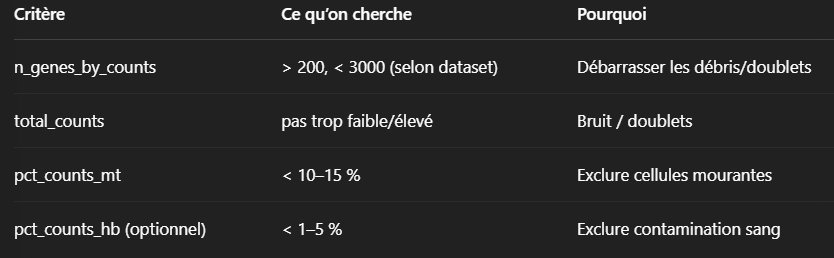

![image.png](attachment:image.png)

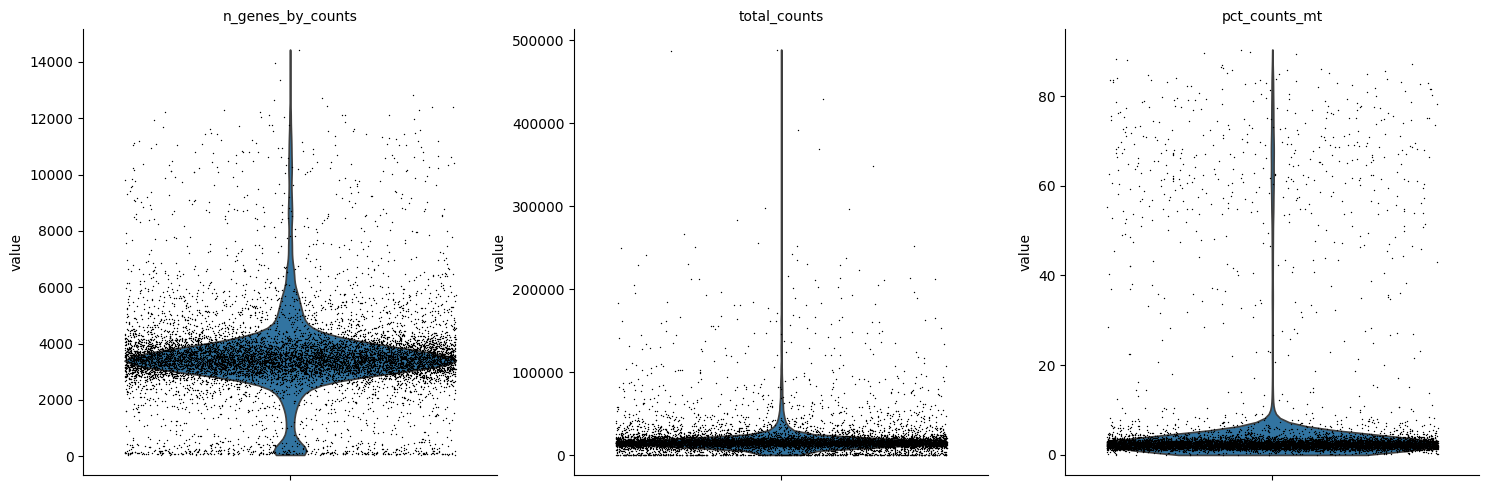

In [4]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

Repérer des cellules extrêmes :

Trop peu de gènes (probablement du bruit)

Trop de gènes ou trop de total_counts (peut-être un doublet)

Trop de mitochondrial → cellule en souffrance



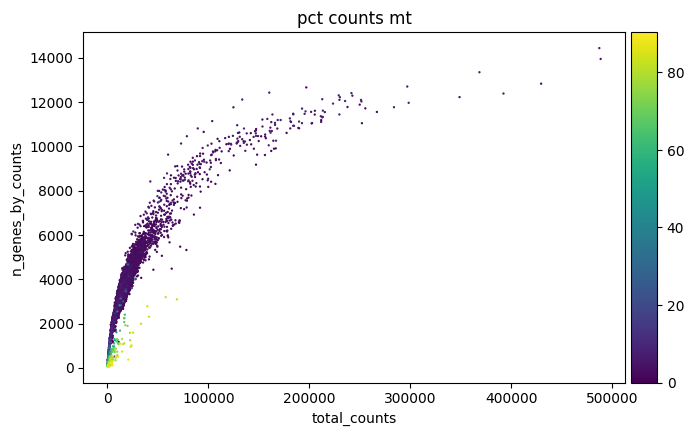

In [8]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Des points isolés en bas à gauche → peu de gènes et de counts = cellules mortes ou gouttelettes vides.

Des points très à droite/haut → trop de gènes et de counts = suspects de doublets.

Des points avec couleur très chaude (jaune/orange) = trop de mitochondrial, ce qui suggère une souffrance cellulaire.


In [6]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs["pct_counts_mt"] < 20, :]

min_genes=100 : t’élimines les gouttelettes vides ou les cellules mortes qui ont quasi rien détecté.

min_cells=3 : t’élimines les gènes très peu exprimés (bruit technique souvent), car ils n’aident pas pour la variation globale.

"pct_counts_mt" < 20, : 

Un pourcentage élevé (>15–20%) des transcrits mitochondriaux indique que la cellule est probablement :

endommagée (membrane cassée → fuite des ARN)

ou sous stress

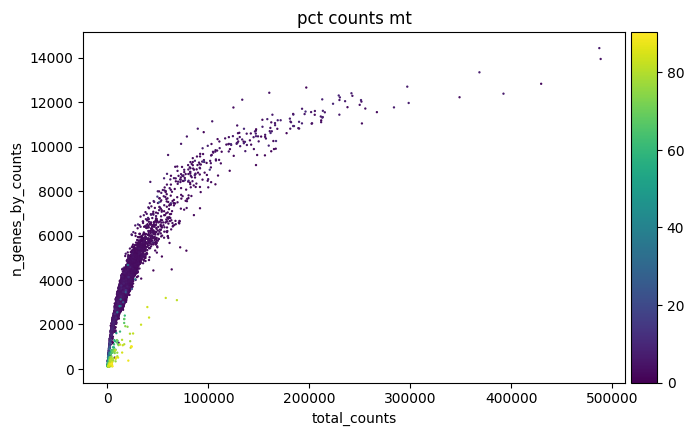

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

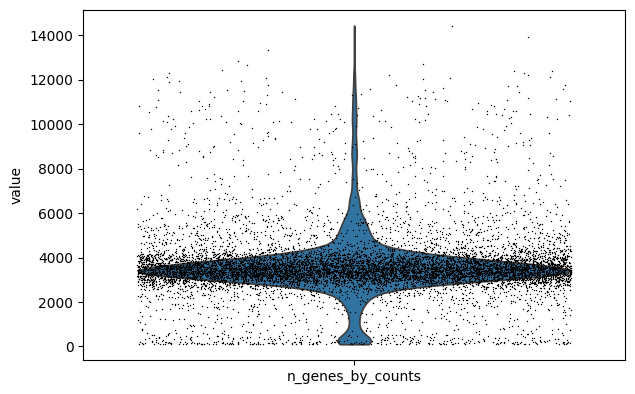

In [8]:
# distribution
sc.pl.violin(adata, "n_genes_by_counts", jitter=0.4)

# exemple : seuil à 6000
adata = adata[adata.obs["n_genes_by_counts"] < 6000, :]


In [ ]:
adata = adata[adata.obs["total_counts"] > 500, :]


Cellules avec < 500 UMIs sont parfois du bruit ou mortes.


Possibilité QC automatique : IQR 

L’IQR est l’intervalle entre le 1er quartile (Q1) et le 3e quartile (Q3)

Restart kernel

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Chargement du fichier HDF5
adata = sc.read_10x_h5("./../runs/filtered_feature_bc_matrix.h5")

#Ajout d'un nom à l'objet AnnData (utile si plusieurs datasets)
adata.var_names_make_unique()

adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")


sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)


/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


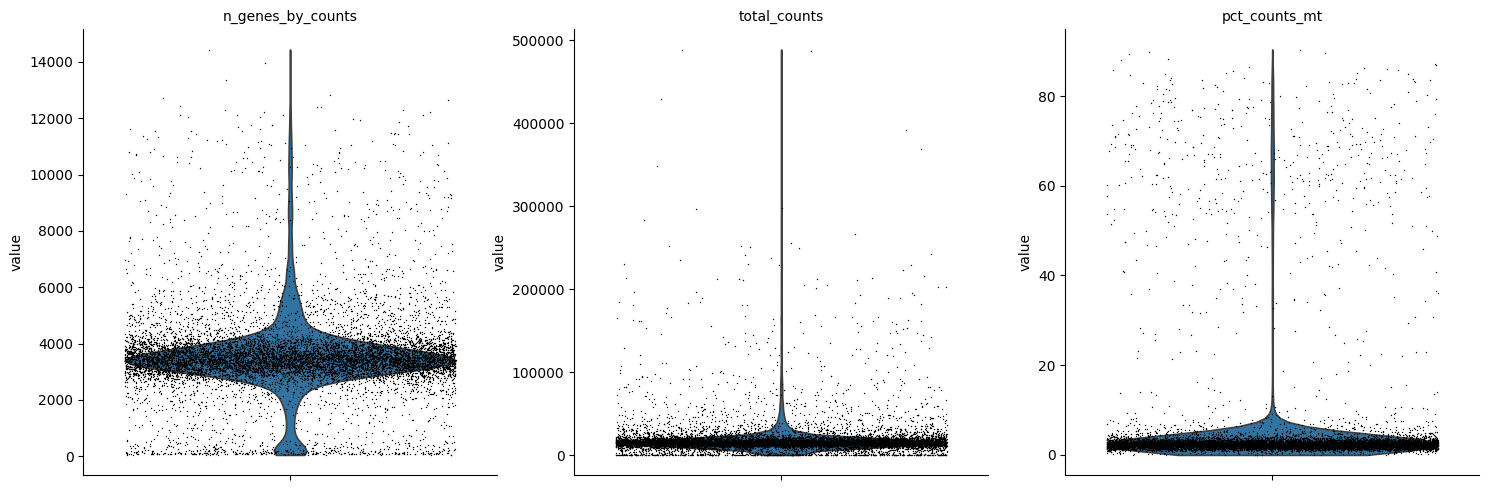

In [2]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


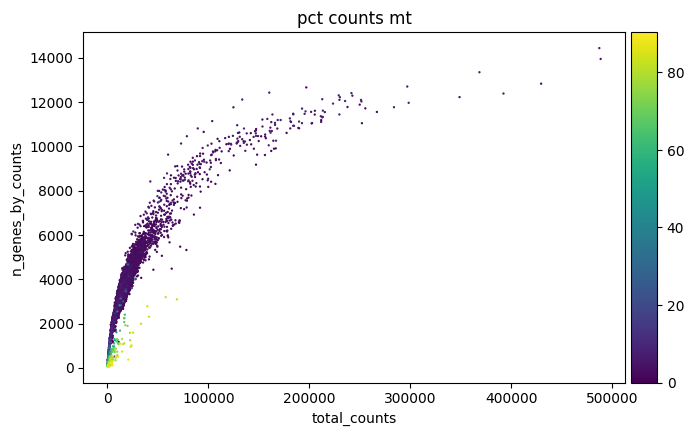

In [3]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [4]:
def filter_by_iqr(adata, column, direction="both", iqr_multiplier=1.5):
    """
    Filtre les cellules selon l'IQR sur une colonne donnée d'adata.obs.
    
    Parameters:
    - adata : objet AnnData
    - column : colonne sur laquelle appliquer le filtre (e.g. "n_genes_by_counts")
    - direction : "both", "upper", "lower"
    - iqr_multiplier : facteur pour déterminer les limites (1.5 par défaut)
    """
    values = adata.obs[column]
    q1 = np.percentile(values, 25)
    q3 = np.percentile(values, 75)
    iqr = q3 - q1

    lower_bound = q1 - iqr_multiplier * iqr
    upper_bound = q3 + iqr_multiplier * iqr

    print(f"{column}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")
    print(f"Filtering between {lower_bound:.2f} and {upper_bound:.2f}")

    if direction == "both":
        keep = (values >= lower_bound) & (values <= upper_bound)
    elif direction == "lower":
        keep = values >= lower_bound
    elif direction == "upper":
        keep = values <= upper_bound
    else:
        raise ValueError("Direction must be 'both', 'upper', or 'lower'")

    filtered = adata[keep].copy()
    print(f"Filtered from {adata.n_obs} to {filtered.n_obs} cells.")
    return filtered


In [5]:
# Filtrage automatique sur :
adata = filter_by_iqr(adata, "n_genes_by_counts", direction="both")
adata = filter_by_iqr(adata, "total_counts", direction="both")
adata = filter_by_iqr(adata, "pct_counts_mt", direction="upper")


n_genes_by_counts: Q1=3082.00, Q3=3863.00, IQR=781.00
Filtering between 1910.50 and 5034.50


Filtered from 10645 to 9065 cells.
total_counts: Q1=12915.00, Q3=17886.00, IQR=4971.00
Filtering between 5458.50 and 25342.50
Filtered from 9065 to 8775 cells.
pct_counts_mt: Q1=1.84, Q3=2.81, IQR=0.97
Filtering between 0.38 and 4.27
Filtered from 8775 to 8559 cells.


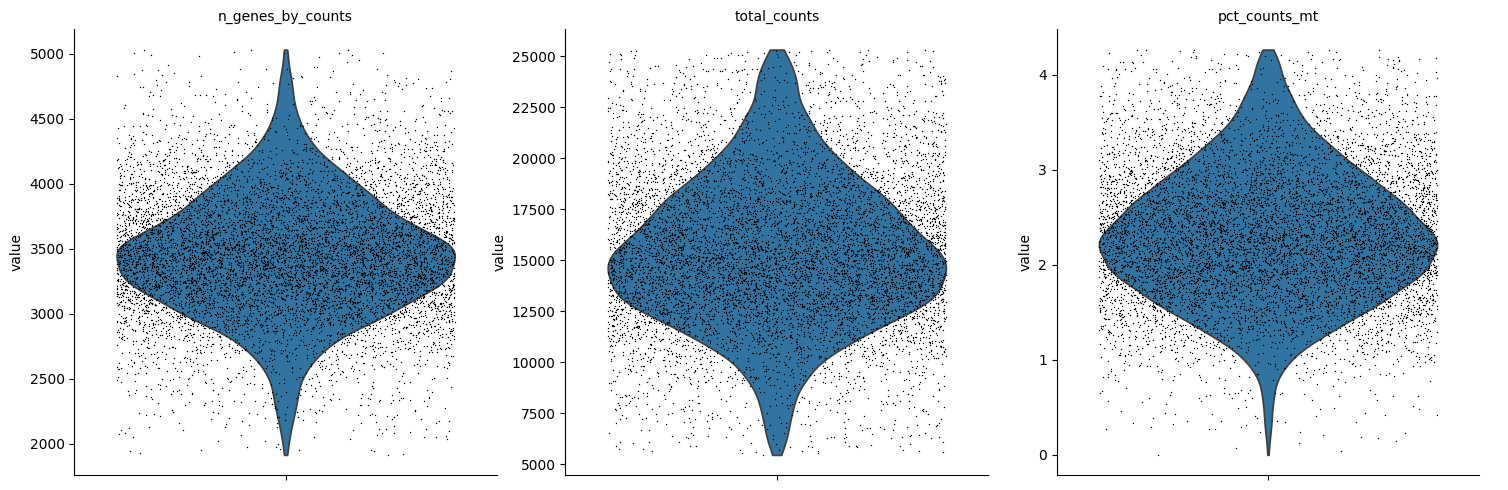

In [6]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)


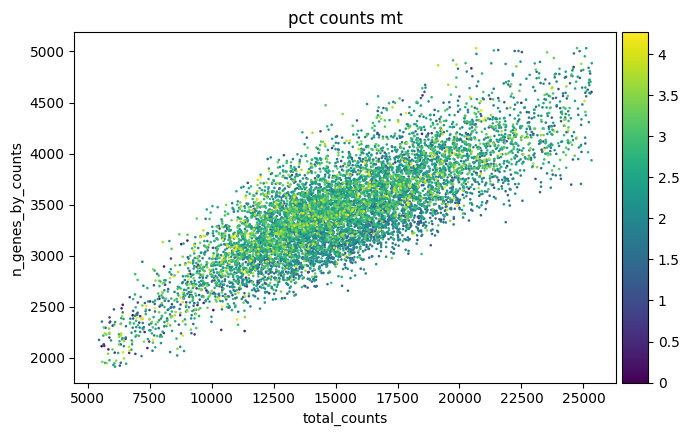

In [7]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

Normalisation du nombre de gènes dans chaque cellule.

In [8]:
sc.pp.normalize_total(adata, target_sum=1e4)

In [9]:
 # Applique la transformation log(X + 1) aux données normalisées
sc.pp.log1p(adata)

sc.pp.highly_variable_genes calcule la relation entre l'expression moyenne et la variance pour chaque gène et marque ceux qui sont "anormalement" variables (probablement biologiquement intéressants). Les paramètres min_mean, max_mean, min_disp aident à affiner cette sélection.
sc.pl.highly_variable_genes permet de visualiser quels gènes ont été sélectionnés.

adata.raw = adata est une étape importante : elle copie l'état actuel (avec tous les gènes) dans un emplacement spécial (.raw). Cela vous permettra plus tard d'examiner l'expression de n'importe quel gène (même non-HVG).

adata = adata[:, adata.var.highly_variable] filtre la matrice de données principale pour ne garder que les colonnes (gènes) marquées comme highly_variable. Cela réduit considérablement la taille des données pour les étapes suivantes, les rendant plus rapides et souvent moins bruitées.

In [10]:
# Identifier les gènes dont la variance est plus élevée que prévu pour leur niveau d'expression moyen
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

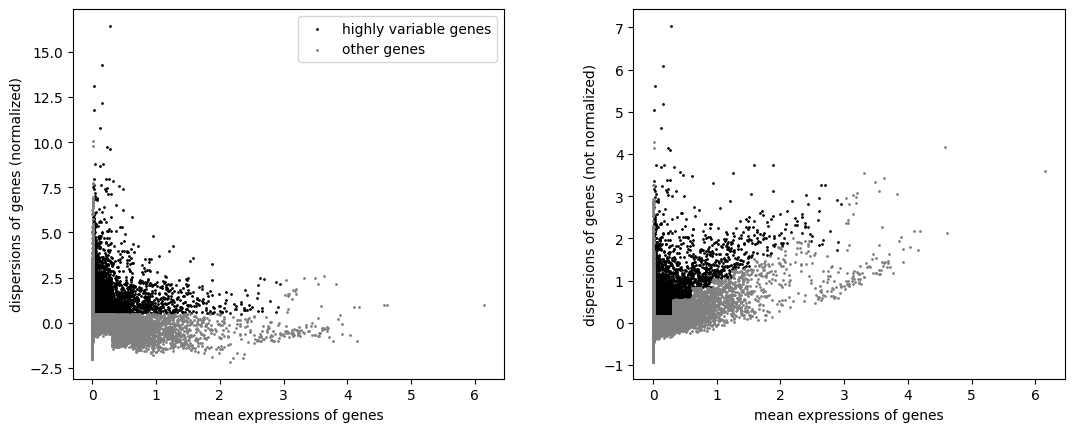

In [11]:
#Visualiser les gènes sélectionnés sur un graphique moyenne-variance
sc.pl.highly_variable_genes(adata)

# Sauvegarder les données actuelles (tous les gènes, norm+log) avant de ne garder que les HVGs
adata.raw = adata

In [12]:
# Réduire l'objet `adata` pour ne contenir que les lignes (cellules) et les colonnes (gènes) identifiées comme HVG
adata = adata[:, adata.var.highly_variable]

Ajuster l'échelle de l'expression de chaque gène HVG pour que tous aient une importance comparable (moyenne 0, variance 1) dans les analyses suivantes comme une PCA.

In [13]:
# Centrer (moyenne=0) et réduire (variance=1) les données pour chaque gène HVG
# max_value=10 limite l'influence de valeurs extrêmes très rares
sc.pp.scale(adata, max_value=10)

/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/scanpy/preprocessing/_scale.py:317: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


Même après log-transformation, les gènes HVG peuvent avoir des plages de valeurs différentes. Le PCA (prochaine étape) est sensible à ces différences d'échelle.

sc.pp.scale modifie les valeurs de adata.X (qui contient maintenant seulement les HVGs) pour que chaque gène (colonne) ait une moyenne de 0 et une variance de 1 sur l'ensemble des cellules.

Cela garantit que tous les HVGs contribuent de manière plus équitable à l'analyse PCA, basée sur leur profil de variation plutôt que sur leur amplitude numérique. max_value=10 empêche quelques valeurs extrêmes de fausser la mise à l'échelle.

Réduction de Dimensionnalité (PCA)

Réduire les dimensions (maintenant les gènes HVG mis à l'échelle) à quelques dizaines de "composantes principales" (PCs) qui résument l'essentiel de la variation biologique.

Graphe pour décider du nombre de PCs utiles

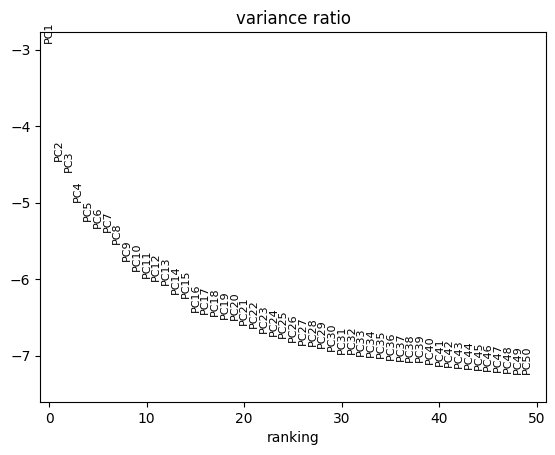

In [14]:
# Calculer PCA
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [15]:
# Construire le graphe de voisinage basé sur les PCs sélectionnées
# !! Remplacez n_pcs=30 par le nombre choisi
sc.pp.neighbors(adata, n_neighbors=15, n_pcs=30)

/data/home/aboussif/work/scRNAseq/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-04-08 16:49:51.492495: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-08 16:49:51.498611: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-04-08 16:49:51.512431: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744123791.535372  886270 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744123791.543227  886270 cuda_bl

In [16]:
sc.tl.umap(adata)

In [18]:
pip install igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 28.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [19]:
# Applique le clustering Leiden sur les voisins définis précédemment
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)


In [21]:
print(adata.obs.columns)


Index(['n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts',
       'log1p_total_counts', 'pct_counts_in_top_50_genes',
       'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes',
       'pct_counts_in_top_500_genes', 'total_counts_mt',
       'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo',
       'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb',
       'log1p_total_counts_hb', 'pct_counts_hb', 'leiden'],
      dtype='object')


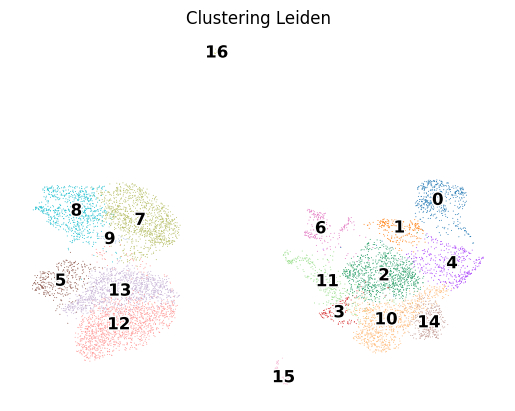

In [23]:
sc.pl.umap(
    adata,
    color="leiden",
    title="Clustering Leiden",
    frameon=False,
    legend_loc="on data",
    legend_fontsize=12,
    legend_fontoutline=2,   
    size=2,  # Réduit la taille des points pour éviter les chevauchements
)


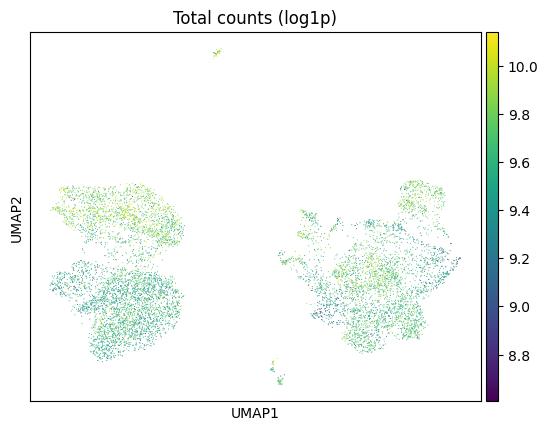

In [27]:
sc.pl.umap(
    adata,
    color="log1p_total_counts", # Comptes totaux de gènes (log-transformés)
    title="Total counts (log1p)",
    size=2,
)


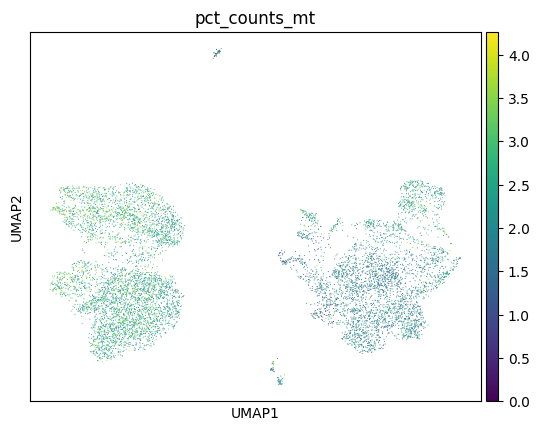

In [28]:
sc.pl.umap(
    adata,
    color="pct_counts_mt",  # Pourcentage de gènes mitochondriaux
    size=2,
)


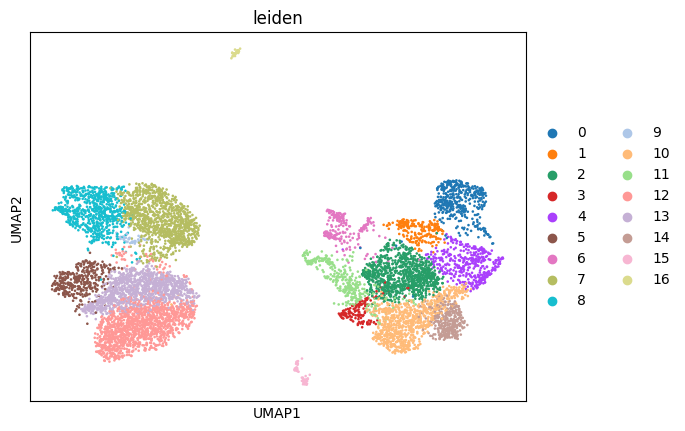

In [31]:
sc.pl.umap(adata, color=["leiden"])


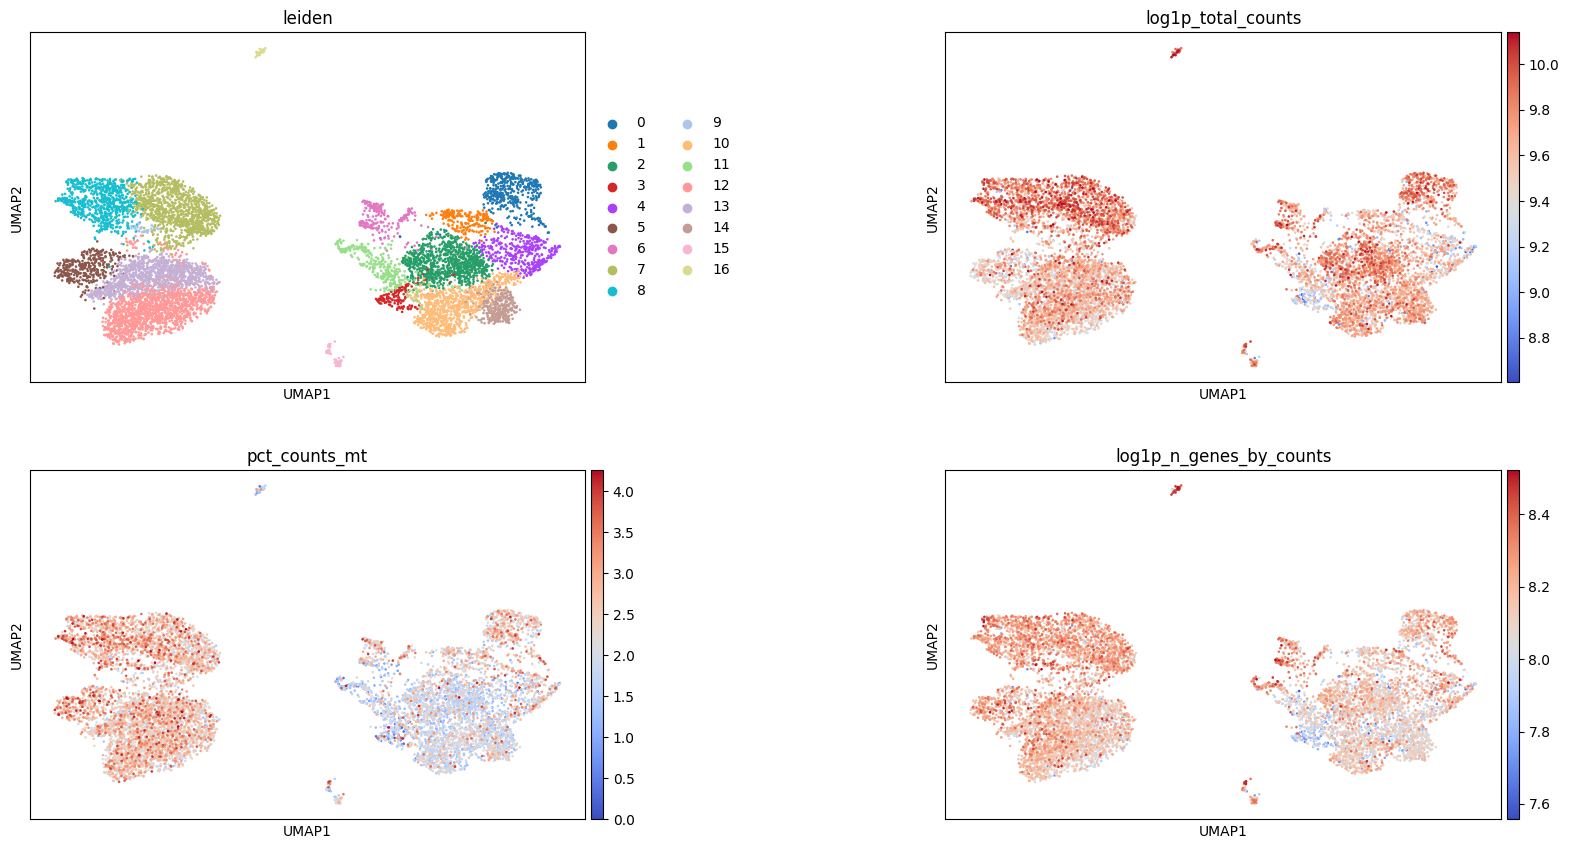

In [32]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,  # Espace horizontal entre les panneaux
    ncols=2,
    color_map = "coolwarm"  # Nombre de colonnes pour afficher les graphiques
)


In [33]:
# Analyse d'expression différentielle entre les clusters
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')  # Ou 'wilcoxon', 'logreg', etc.


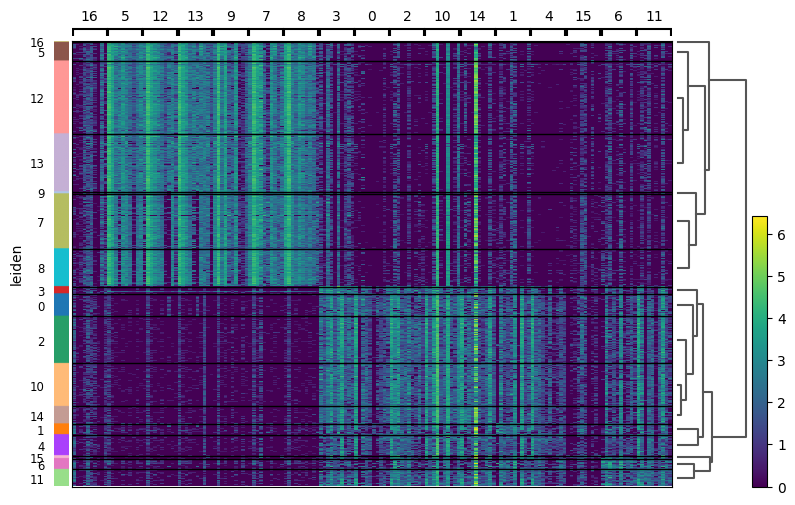

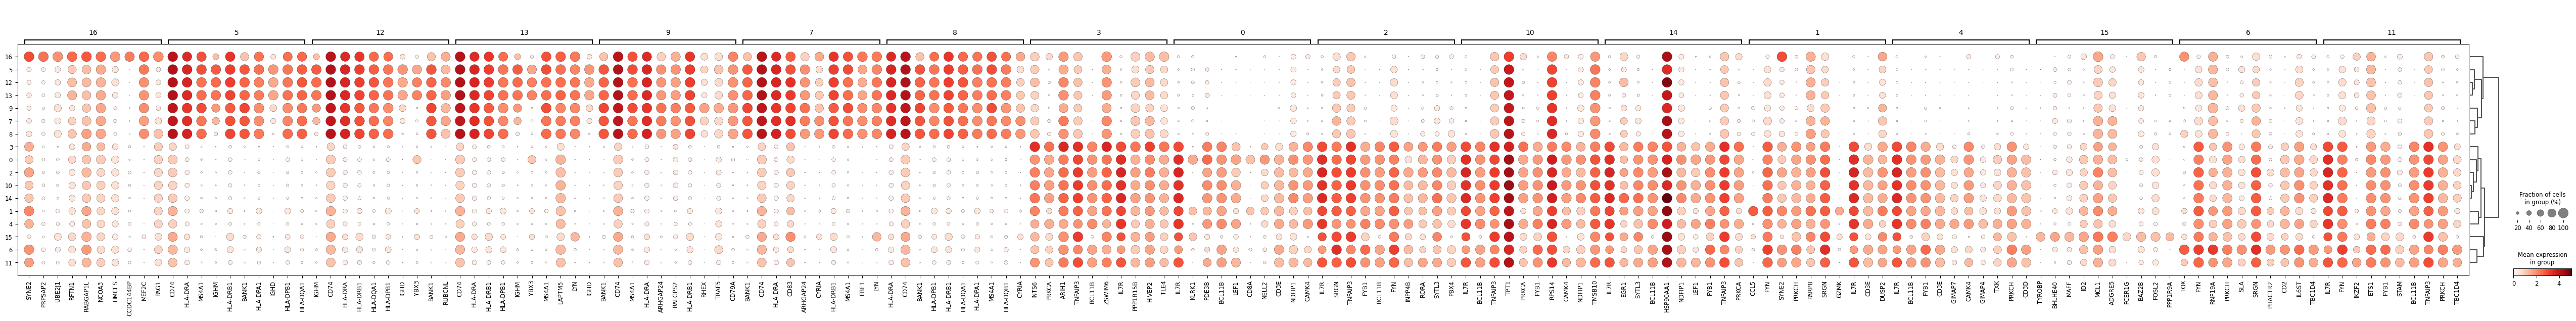

In [38]:
# Visualisation des gènes différentiels avec un heatmap
sc.pl.rank_genes_groups_heatmap(adata, n_genes=10, groupby='leiden', cmap='viridis', dendrogram=True)

# Visualisation avec un dot plot
sc.pl.rank_genes_groups_dotplot(adata, n_genes=10, groupby='leiden')


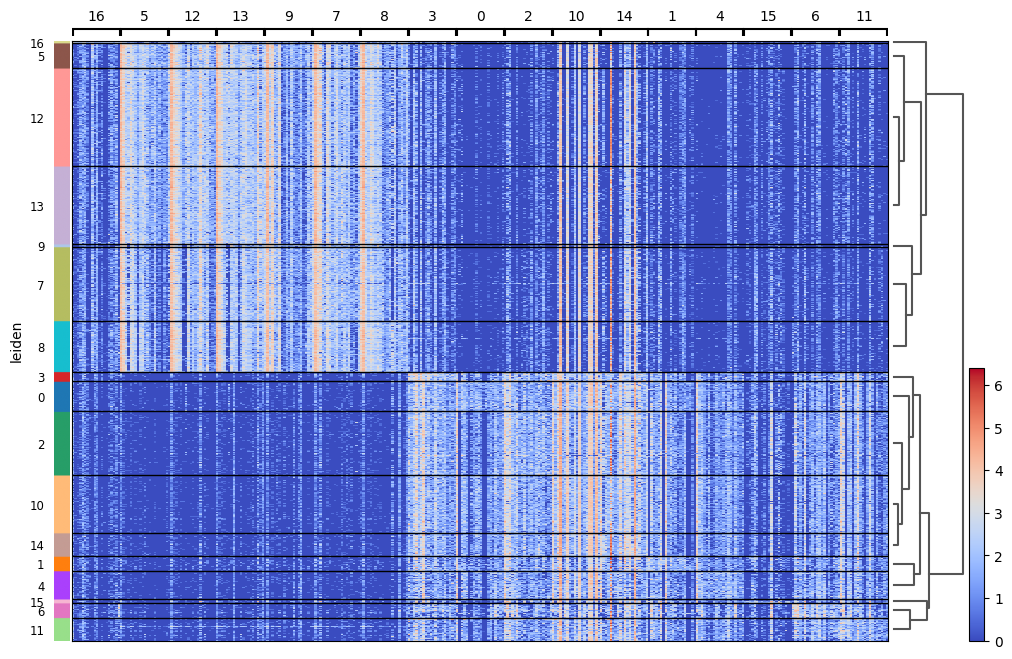

AttributeError: 'NoneType' object has no attribute 'figure'